In [8]:
import torch

In [9]:
# torch.load()
# torch.save()
# torch.nn.Module.load_state_dict()
# torch.optim.Adam.state_dict()

In [10]:
w = 0.7

b = 0.3

In [11]:
X = torch.arange(0,100).unsqueeze(1)
X

tensor([[ 0],
        [ 1],
        [ 2],
        [ 3],
        [ 4],
        [ 5],
        [ 6],
        [ 7],
        [ 8],
        [ 9],
        [10],
        [11],
        [12],
        [13],
        [14],
        [15],
        [16],
        [17],
        [18],
        [19],
        [20],
        [21],
        [22],
        [23],
        [24],
        [25],
        [26],
        [27],
        [28],
        [29],
        [30],
        [31],
        [32],
        [33],
        [34],
        [35],
        [36],
        [37],
        [38],
        [39],
        [40],
        [41],
        [42],
        [43],
        [44],
        [45],
        [46],
        [47],
        [48],
        [49],
        [50],
        [51],
        [52],
        [53],
        [54],
        [55],
        [56],
        [57],
        [58],
        [59],
        [60],
        [61],
        [62],
        [63],
        [64],
        [65],
        [66],
        [67],
        [68],
        [69],
        [70],
      

In [76]:
y = w * X + b
y

tensor([[ 0.3000],
        [ 1.0000],
        [ 1.7000],
        [ 2.4000],
        [ 3.1000],
        [ 3.8000],
        [ 4.5000],
        [ 5.2000],
        [ 5.9000],
        [ 6.6000],
        [ 7.3000],
        [ 8.0000],
        [ 8.7000],
        [ 9.4000],
        [10.1000],
        [10.8000],
        [11.5000],
        [12.2000],
        [12.9000],
        [13.6000],
        [14.3000],
        [15.0000],
        [15.7000],
        [16.4000],
        [17.1000],
        [17.8000],
        [18.5000],
        [19.2000],
        [19.9000],
        [20.6000],
        [21.3000],
        [22.0000],
        [22.7000],
        [23.4000],
        [24.1000],
        [24.8000],
        [25.5000],
        [26.2000],
        [26.9000],
        [27.6000],
        [28.3000],
        [29.0000],
        [29.7000],
        [30.4000],
        [31.1000],
        [31.8000],
        [32.5000],
        [33.2000],
        [33.9000],
        [34.6000],
        [35.3000],
        [36.0000],
        [36.

In [84]:
train = int(len(X) * 0.8)
# train
(X_train,X_test,y_train,y_test) = (X[:train],X[train:],y[:train],y[train:])
len(X_train)
# len(X_test)

80

In [85]:
from torch import nn

class LinearModel(nn.Module):
    def __init__(self):
        super().__init__()
        torch.manual_seed(42)
        self.weight = nn.Parameter(torch.randn(1))
        self.bias = nn.Parameter(torch.randn(1))
    def forward(self,x):
        y_preds = self.weight * x + self.bias
        return y_preds

In [86]:
model = LinearModel()

loss_fn = torch.nn.L1Loss()

optm_fn = torch.optim.Adam(
    params=model.parameters(),
    lr=0.01
)

epochs = 499

for epoch in range(epochs):

    model.train(True)  # training mode

    # Forward pass
    y_pred = model(X_train)

    # Calculate loss
    loss = loss_fn(y_pred, y_train)

    # Zero previous gradients
    optm_fn.zero_grad()

    # Backpropagation
    loss.backward()

    # Update parameters
    optm_fn.step()

    print(f"Epoch: {epoch} | Loss: {loss.item()}")

Epoch: 0 | Loss: 14.521921157836914
Epoch: 1 | Loss: 14.116920471191406
Epoch: 2 | Loss: 13.711921691894531
Epoch: 3 | Loss: 13.306921005249023
Epoch: 4 | Loss: 12.901921272277832
Epoch: 5 | Loss: 12.49692153930664
Epoch: 6 | Loss: 12.09192180633545
Epoch: 7 | Loss: 11.686922073364258
Epoch: 8 | Loss: 11.281923294067383
Epoch: 9 | Loss: 10.876924514770508
Epoch: 10 | Loss: 10.471923828125
Epoch: 11 | Loss: 10.066924095153809
Epoch: 12 | Loss: 9.661925315856934
Epoch: 13 | Loss: 9.256925582885742
Epoch: 14 | Loss: 8.851924896240234
Epoch: 15 | Loss: 8.446927070617676
Epoch: 16 | Loss: 8.041925430297852
Epoch: 17 | Loss: 7.636927127838135
Epoch: 18 | Loss: 7.232146263122559
Epoch: 19 | Loss: 6.827413082122803
Epoch: 20 | Loss: 6.422691345214844
Epoch: 21 | Loss: 6.017982006072998
Epoch: 22 | Loss: 5.613280773162842
Epoch: 23 | Loss: 5.208587646484375
Epoch: 24 | Loss: 4.803902626037598
Epoch: 25 | Loss: 4.399221897125244
Epoch: 26 | Loss: 3.9945456981658936
Epoch: 27 | Loss: 3.5900001525

In [87]:
# Testing phase

model.eval()

with torch.inference_mode():
    print(len(X_test))
    test_pred = model(X_test)
    test_loss = loss_fn(test_pred, y_test)
    print(len(test_pred))

print(f"Test Loss: {test_loss.item()}")
print(model.state_dict())

20
20
Test Loss: 0.006654548458755016
OrderedDict({'weight': tensor([0.7001]), 'bias': tensor([0.3014])})


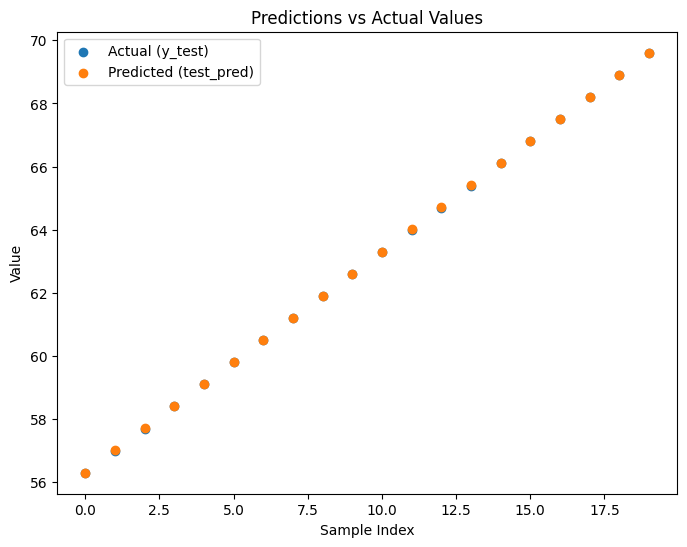

In [88]:
import matplotlib.pyplot as plt

# Convert tensors to numpy if needed
test_pred_np = test_pred.cpu().numpy()
y_test_np = y_test.cpu().numpy()

plt.figure(figsize=(8, 6))

# Actual values
plt.scatter(
    range(len(y_test_np)),
    y_test_np,
    label="Actual (y_test)"
)

# Predicted values
plt.scatter(
    range(len(test_pred_np)),
    test_pred_np,
    label="Predicted (test_pred)"
)

plt.xlabel("Sample Index")
plt.ylabel("Value")
plt.title("Predictions vs Actual Values")
plt.legend()

plt.show()